In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')
%matplotlib inline

import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(style='whitegrid', context='notebook')

In [3]:
df = pd.read_csv(r'/"PATH"/f1_pitstops_cleaned_2018_2024.csv', encoding='utf-8', delimiter=',')

In [4]:
print('Dataset loaded with shape:', df.shape)
df.head()

Dataset loaded with shape: (7189, 32)


,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race_Name,...,Position_Changes,Driver_Aggression_Score,Abbreviation,Stint,Tire_Compound,Stint_Length,Pit_Lap,Pit_Time,Pit_Time_Clean,Is_Final_Stint
0,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.000000,6.755003,VET,1.0,ULTRASOFT,25.0,26.0,21.787,21.787,False
1,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.000000,6.755003,VET,2.0,SOFT,32.0,NaN,Final Stint,NaN,True
2,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.043478,6.754254,HAM,1.0,ULTRASOFT,17.0,19.0,21.821,21.821,False
3,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.043478,6.754254,HAM,2.0,SOFT,39.0,NaN,Final Stint,NaN,True
4,2018,1,Albert Park Grand Prix Circuit,Kimi RÃƒÂ¤ikkÃƒÂ¶nen,Ferrari,58,3,1,21.421,Australian Grand Prix,...,0.086957,6.818562,RAI,1.0,ULTRASOFT,17.0,18.0,21.421,21.421,False


In [5]:
if df['Date'].dtype == 'object':
    try:
        df['Date'] = pd.to_datetime(df['Date'])
        print("'Date' column successfully converted to datetime")
    except Exception as e:
        print("Error converting 'Date' column:", e)

'Date' column successfully converted to datetime


In [6]:
missing = df.isnull().sum()
print('Missing values in each column:')
print(missing[missing > 0])


Missing values in each column:
Race_Name            364
Date                 364
Time_of_race         364
Location             364
Country              364
Air_Temp_C           364
Track_Temp_C         364
Humidity_Percent     364
Wind_Speed_KMH       364
Stint                 96
Stint_Length          96
Pit_Lap             2625
Pit_Time              96
Pit_Time_Clean      2625
dtype: int64


In [7]:
df = df.dropna()
print('Shape after dropping missing values:', df.shape)

Shape after dropping missing values: (4334, 32)


In [8]:
df = df.drop_duplicates()
print('Shape after dropping duplicate rows:', df.shape)

Shape after dropping duplicate rows: (4334, 32)


In [9]:
print(df.describe())

            Season        Round         Laps     Position  TotalPitStops  \
count  4334.000000  4334.000000  4334.000000  4334.000000    4334.000000   
mean   2021.445316    10.420166    57.763267     9.971158       2.309414   
std       1.920202     6.027667    11.282589     5.470383       1.161351   
min    2018.000000     1.000000     1.000000     1.000000       1.000000   
25%    2020.000000     5.000000    52.000000     5.000000       2.000000   
50%    2022.000000    10.000000    57.000000    10.000000       2.000000   
75%    2023.000000    15.000000    66.000000    15.000000       3.000000   
max    2024.000000    24.000000    87.000000    20.000000       7.000000   

       AvgPitStopTime   Air_Temp_C  Track_Temp_C  Humidity_Percent  \
count     4334.000000  4334.000000   4334.000000       4334.000000   
mean       132.955506    19.416188     25.101536         67.510585   
std        275.038339     5.123668      5.224392         14.465258   
min         17.358500     0.387500 

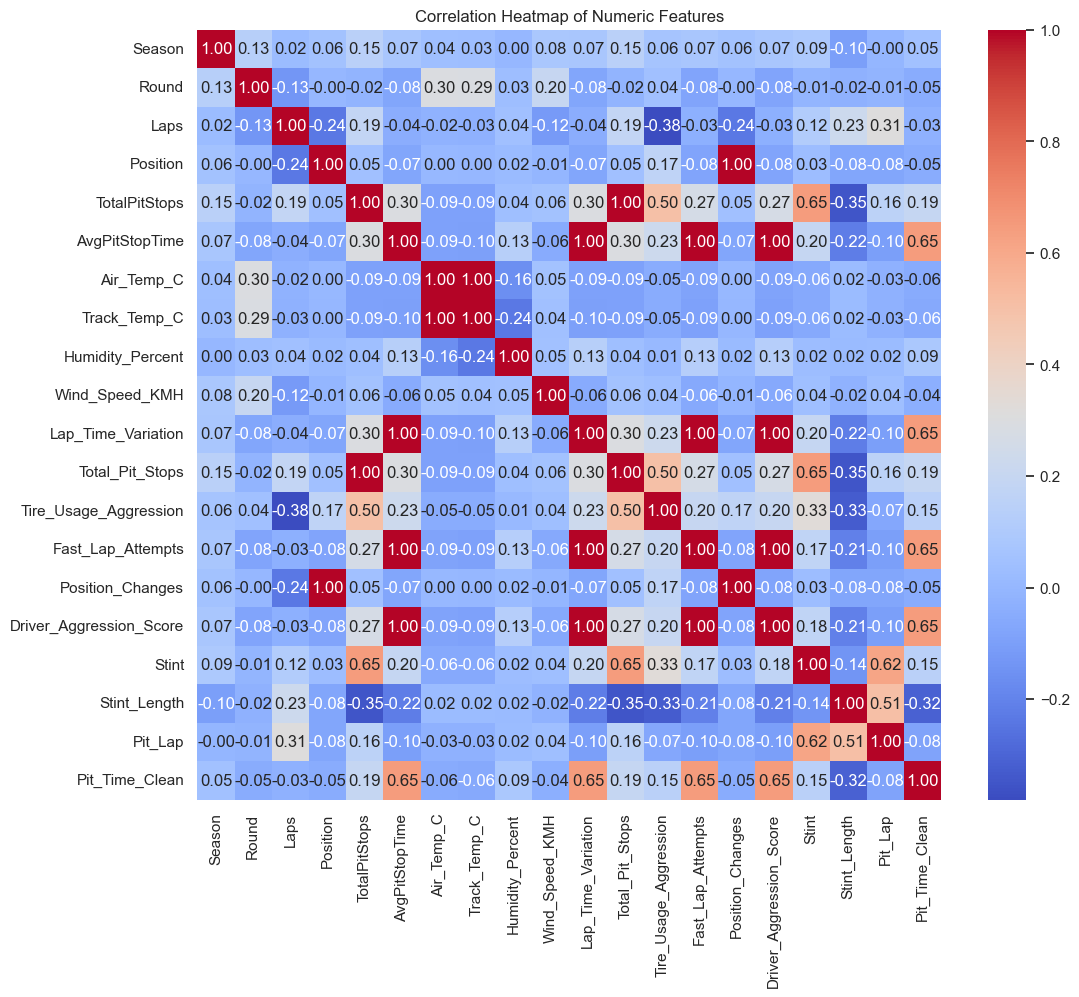

In [10]:
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print('Not enough numeric columns for a meaningful correlation heatmap')

R² score: 1.00


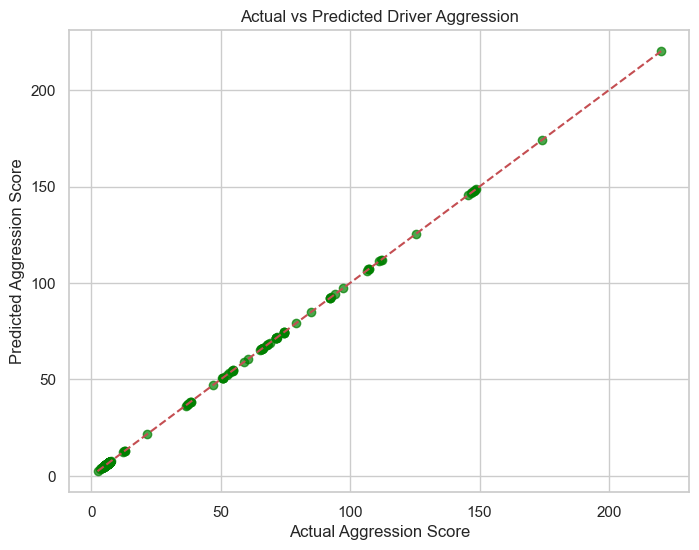

In [34]:
features = [
    'Laps',
    'Position',
    'Total_Pit_Stops',
    'Stint_Length',
    'Air_Temp_C',
    'Track_Temp_C',
    'Humidity_Percent',
    'Wind_Speed_KMH',
    'Fast_Lap_Attempts',
    'Pit_Lap',
    'Is_Final_Stint'
] 
features = [f for f in features if f in df.columns]
target = 'Driver_Aggression_Score'

# Drop rows with NaNs in relevant columns
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

score = r2_score(y_test, y_pred)
print(f'R² score: {score:.2f}') 

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.xlabel('Actual Aggression Score')
plt.ylabel('Predicted Aggression Score')
plt.title('Actual vs Predicted Driver Aggression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Test H1: Pit Stop Time Trends Over Time

In [36]:
def categorize_pit_stop_time(time):
    if time < 30:
        return "Usual"
    elif 30 <= time <= 60:
        return "Unusual"
    else:
        return "Exception"

# Apply categorization
df["PitStopCategory"] = df["AvgPitStopTime"].apply(categorize_pit_stop_time)

# Display category counts
category_counts = df["PitStopCategory"].value_counts()
print("Pit Stop Category Counts:\n", category_counts)


Pit Stop Category Counts:
 Usual        3124
Exception     774
Unusual       436
Name: PitStopCategory, dtype: int64


In [37]:
season_avg = df.groupby("Season")["AvgPitStopTime"].mean()

In [38]:
season_avg

Season
2018     24.825844
2019     25.262760
2020    178.104083
2021    271.937797
2022    125.311353
2023    142.877232
2024    110.273627
Name: AvgPitStopTime, dtype: float64

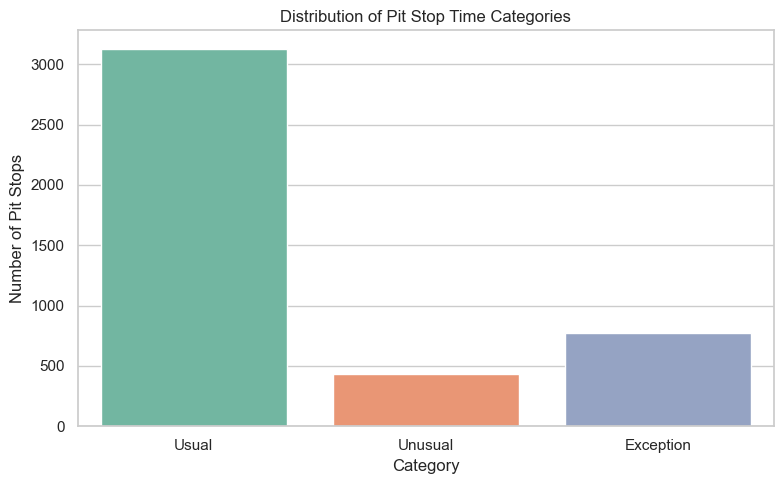

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="PitStopCategory", order=["Usual", "Unusual", "Exception"], palette="Set2")
plt.title("Distribution of Pit Stop Time Categories")
plt.xlabel("Category")
plt.ylabel("Number of Pit Stops")
plt.tight_layout()
plt.savefig("pit_stop_category_distribution.png")
plt.show()


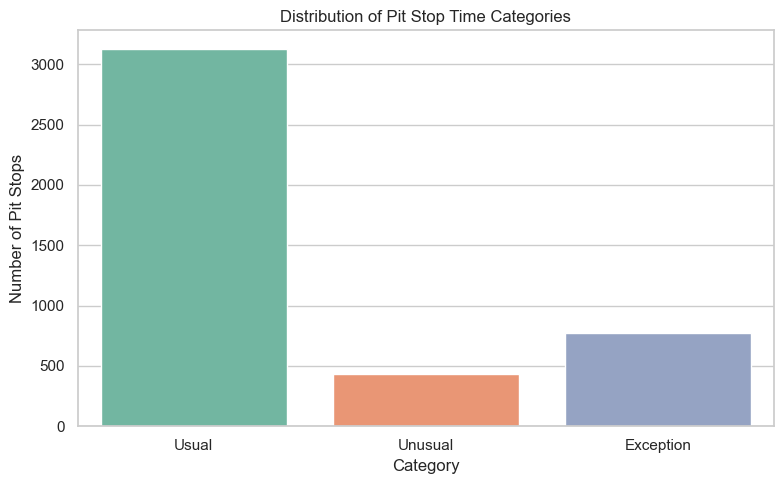

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="PitStopCategory", order=["Usual", "Unusual", "Exception"], palette="Set2")
plt.title("Distribution of Pit Stop Time Categories")
plt.xlabel("Category")
plt.ylabel("Number of Pit Stops")
plt.tight_layout()
plt.savefig("1_pit_stop_category_distribution.png")
plt.show()


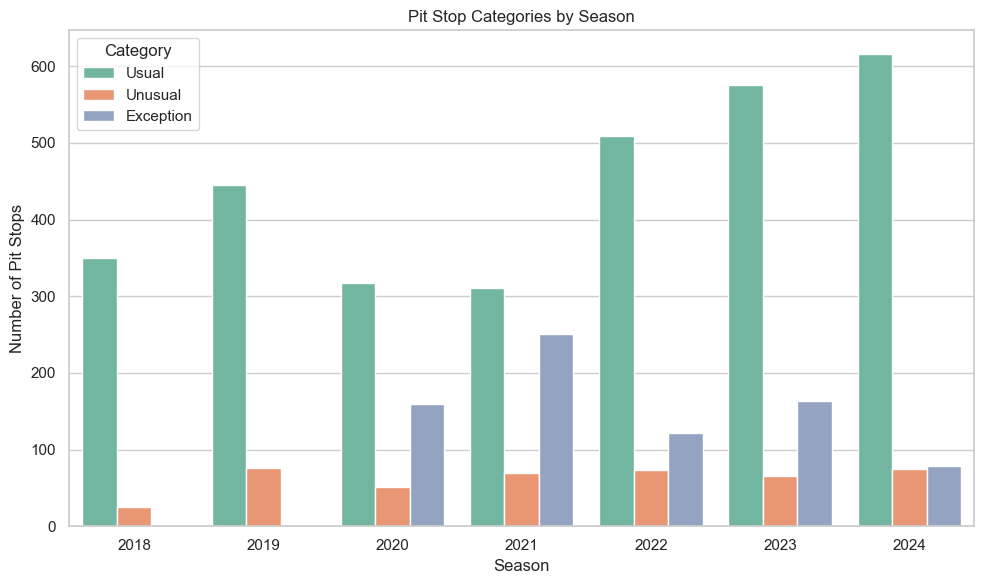

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Season", hue="PitStopCategory", order=sorted(df["Season"].unique()), palette="Set2")
plt.title("Pit Stop Categories by Season")
plt.xlabel("Season")
plt.ylabel("Number of Pit Stops")
plt.legend(title="Category")
plt.tight_layout()
plt.savefig("2_pit_stop_category_by_season.png")
plt.show()


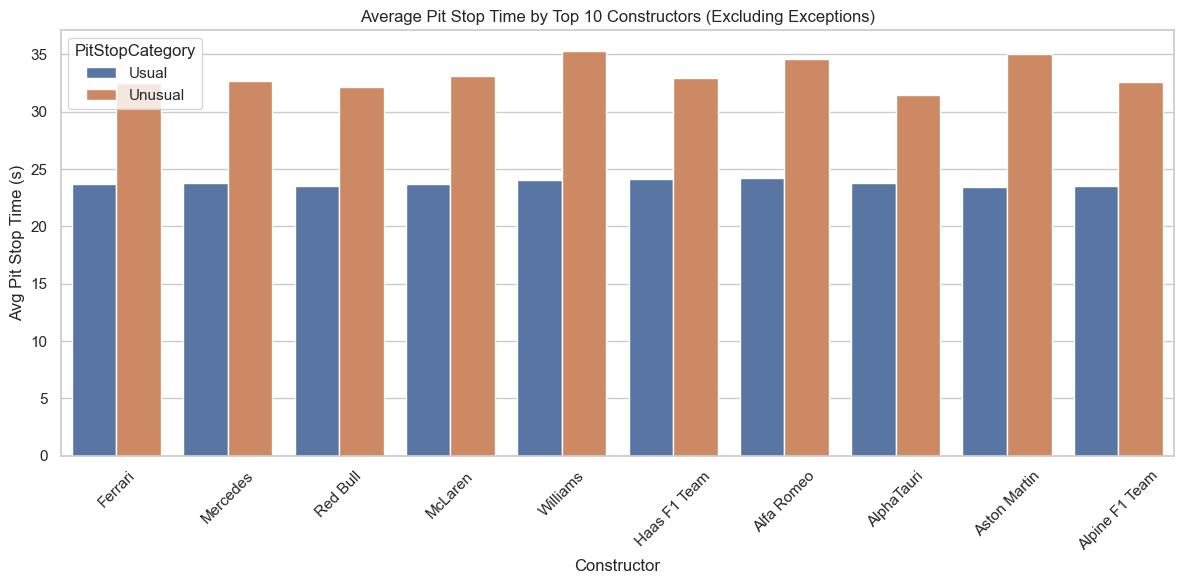

In [42]:
# Filter out 'Exception' category to focus on Usual and Unusual pit stops
filtered_df = df[df["PitStopCategory"].isin(["Usual", "Unusual"])]

# Keep only top 10 constructors by frequency
top_teams = filtered_df['Constructor'].value_counts().nlargest(10).index
filtered_df = filtered_df[filtered_df['Constructor'].isin(top_teams)]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_df, x="Constructor", y="AvgPitStopTime", hue="PitStopCategory", ci=None)
plt.title("Average Pit Stop Time by Top 10 Constructors (Excluding Exceptions)")
plt.xticks(rotation=45)
plt.ylabel("Avg Pit Stop Time (s)")
plt.xlabel("Constructor")
plt.tight_layout()
plt.savefig("3_avg_pit_time_by_constructor_filtered.png")
plt.show()


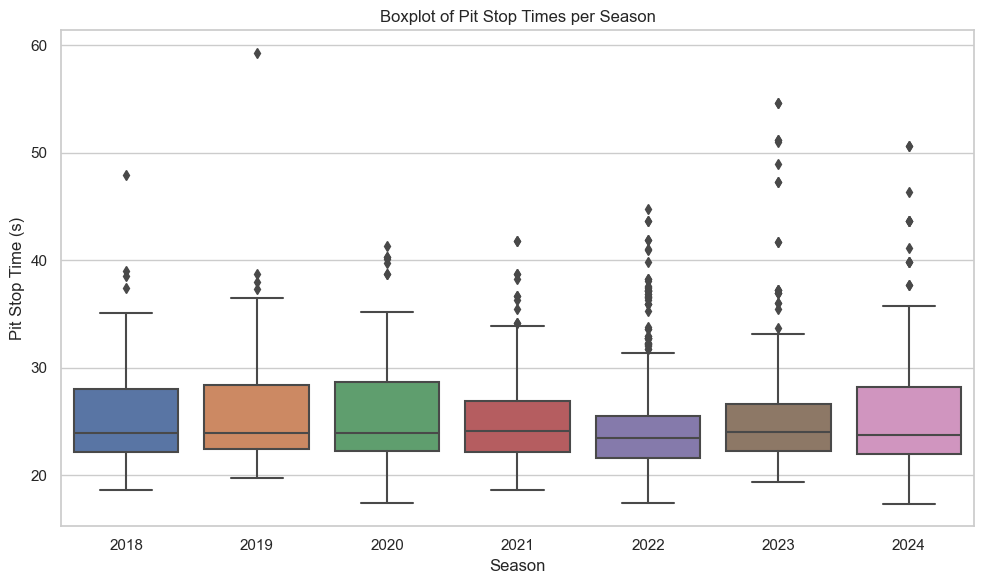

In [43]:
filtered_df = df[df["PitStopCategory"].isin(["Usual", "Unusual"])] = df[df["PitStopCategory"].isin(["Usual", "Unusual"])]
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df, x="Season", y="AvgPitStopTime")
plt.title("Boxplot of Pit Stop Times per Season")
plt.ylabel("Pit Stop Time (s)")
plt.xlabel("Season")
plt.tight_layout()
plt.savefig("4_boxplot_pit_stop_time_per_season.png")
plt.show()

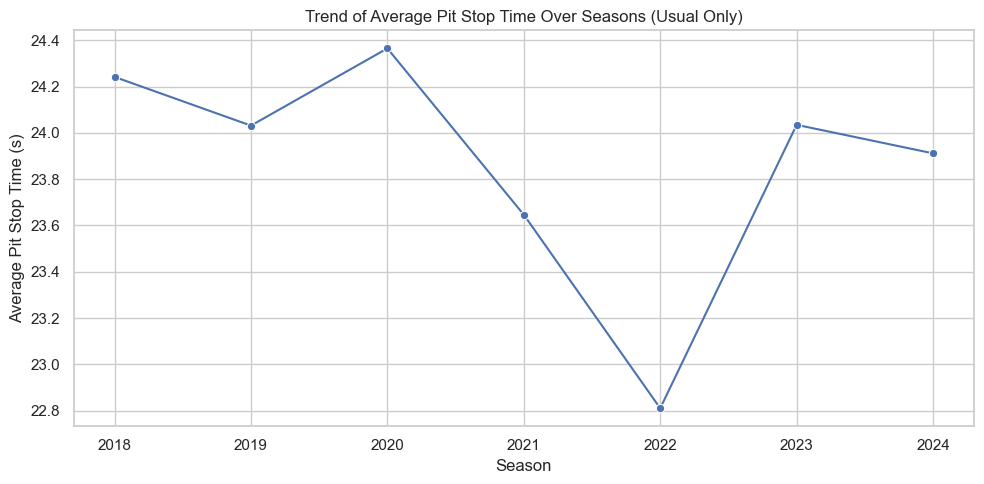

In [44]:
usual_df = df[df["PitStopCategory"] == "Usual"]
avg_trend = usual_df.groupby("Season")["AvgPitStopTime"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_trend, x="Season", y="AvgPitStopTime", marker='o')
plt.title("Trend of Average Pit Stop Time Over Seasons (Usual Only)")
plt.ylabel("Average Pit Stop Time (s)")
plt.xlabel("Season")
plt.tight_layout()
plt.savefig("5_avg_trend_usual_only.png")
plt.show()


# 1. Average Pit Stop Time Per Year (Trend Over Time)

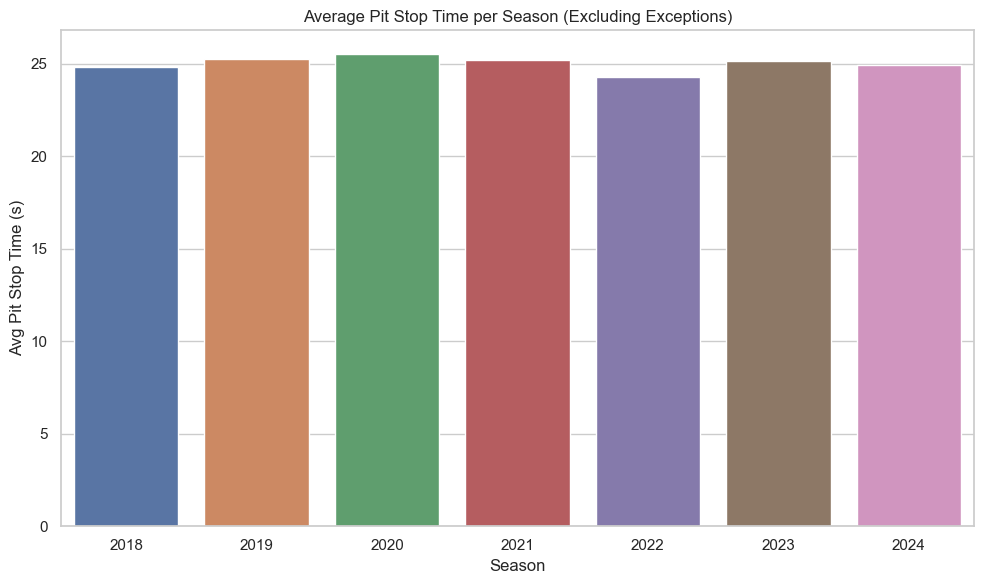

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df[df["PitStopCategory"] != "Exception"], x="Season", y="AvgPitStopTime", ci=None)
plt.title("Average Pit Stop Time per Season (Excluding Exceptions)")
plt.ylabel("Avg Pit Stop Time (s)")
plt.xlabel("Season")
plt.tight_layout()
plt.savefig("1_avg_pit_time_per_season.png")
plt.show()


In [46]:
print(df.columns.tolist())


['Season', 'Round', 'Circuit', 'Driver', 'Constructor', 'Laps', 'Position', 'TotalPitStops', 'AvgPitStopTime', 'Race_Name', 'Date', 'Time_of_race', 'Location', 'Country', 'Air_Temp_C', 'Track_Temp_C', 'Humidity_Percent', 'Wind_Speed_KMH', 'Lap_Time_Variation', 'Total_Pit_Stops', 'Tire_Usage_Aggression', 'Fast_Lap_Attempts', 'Position_Changes', 'Driver_Aggression_Score', 'Abbreviation', 'Stint', 'Tire_Compound', 'Stint_Length', 'Pit_Lap', 'Pit_Time', 'Pit_Time_Clean', 'Is_Final_Stint', 'PitStopCategory']


# 2.  Avg Pit Stop Time by Tire Compound Over Years

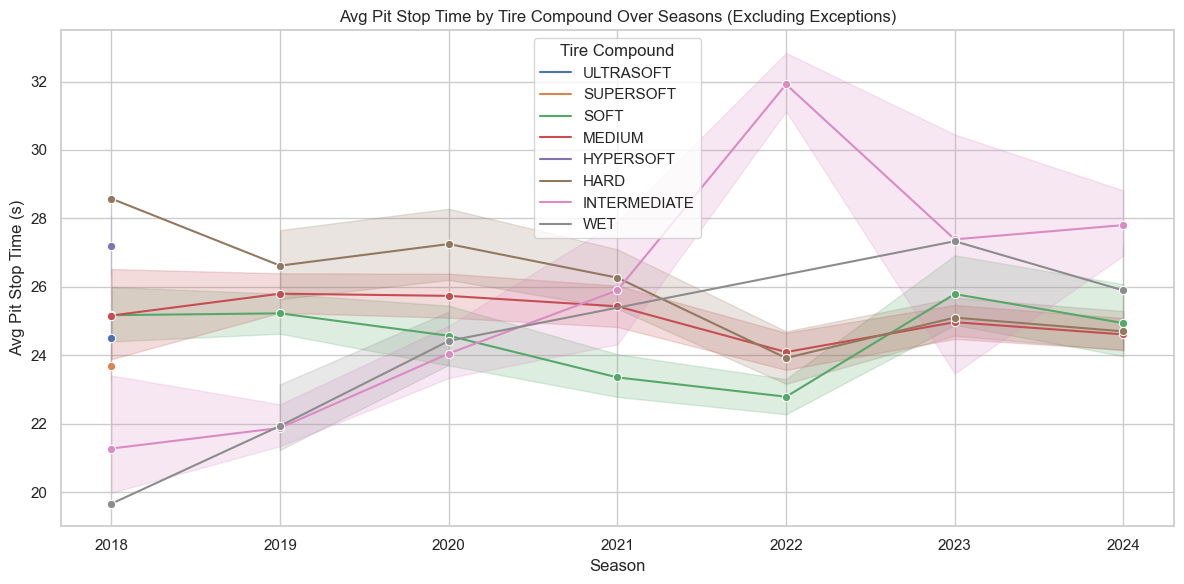

In [48]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df[df["PitStopCategory"] != "Exception"],
    x="Season",
    y="AvgPitStopTime",
    hue="Tire_Compound",
    marker="o"
)
plt.title("Avg Pit Stop Time by Tire Compound Over Seasons (Excluding Exceptions)")
plt.ylabel("Avg Pit Stop Time (s)")
plt.xlabel("Season")
plt.legend(title="Tire Compound")
plt.tight_layout()
plt.savefig("2_avg_pit_by_tire_compound.png")
plt.show()


# 3.  Constructor-wise Pit Stop Strategy Categories

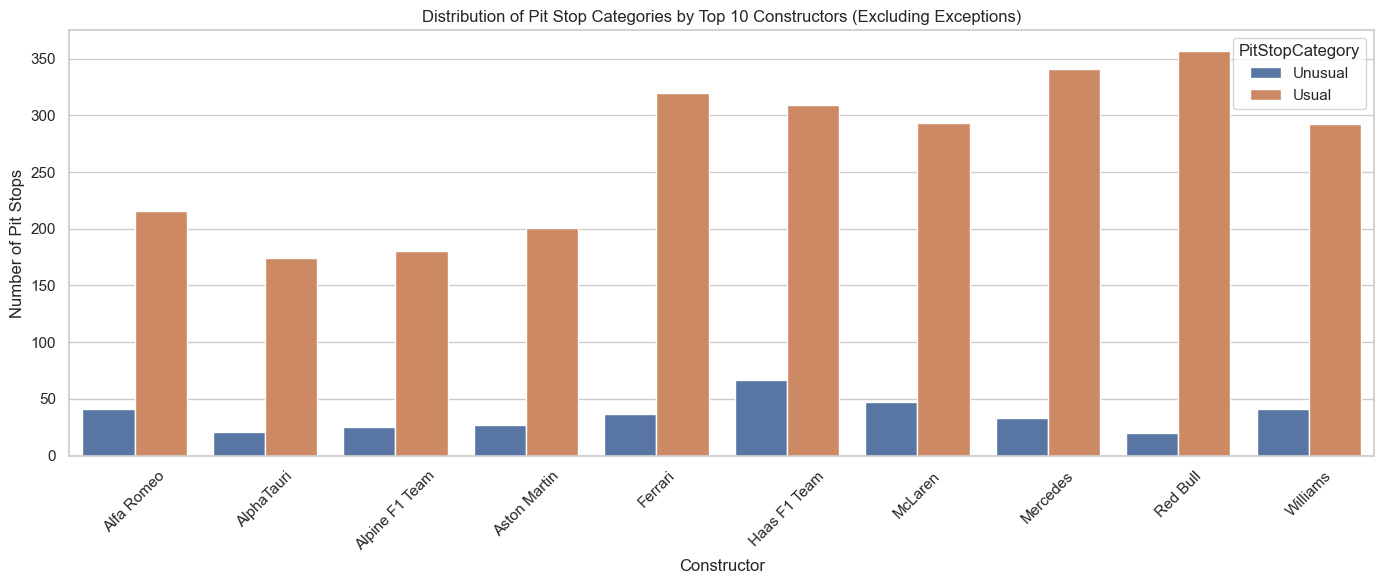

In [49]:
category_counts = df[df["PitStopCategory"] != "Exception"] \
    .groupby(["Constructor", "PitStopCategory"])["AvgPitStopTime"] \
    .count().reset_index(name="Count")

plt.figure(figsize=(14, 6))
sns.barplot(
    data=category_counts[category_counts["Constructor"].isin(df["Constructor"].value_counts().nlargest(10).index)],
    x="Constructor",
    y="Count",
    hue="PitStopCategory"
)
plt.title("Distribution of Pit Stop Categories by Top 10 Constructors (Excluding Exceptions)")
plt.xticks(rotation=45)
plt.ylabel("Number of Pit Stops")
plt.xlabel("Constructor")
plt.tight_layout()
plt.savefig("3_pitstop_category_distribution.png")
plt.show()


# 4.  Unusual Pit Stop Frequency Over Years

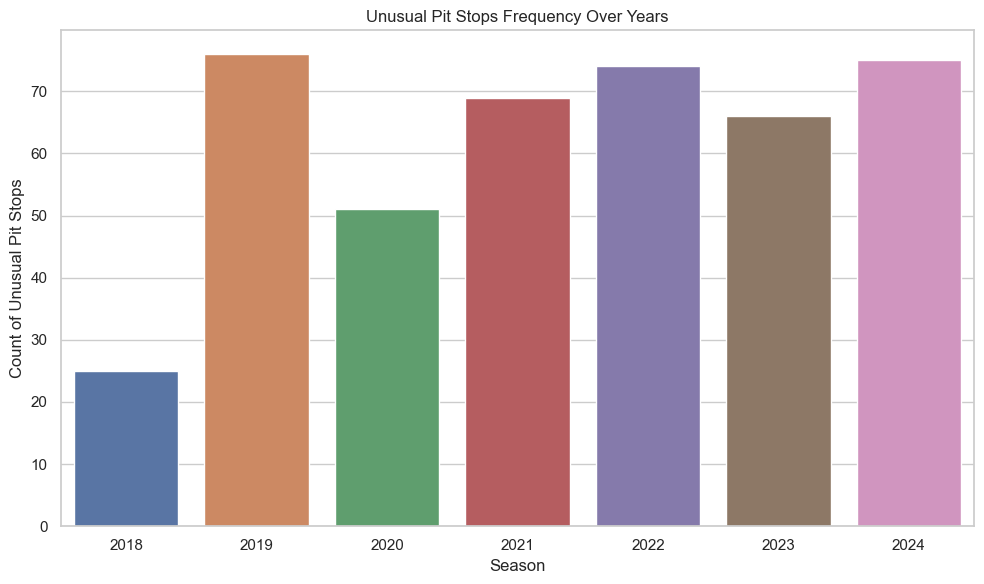

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df[df["PitStopCategory"] == "Unusual"], x="Season", order=sorted(df["Season"].unique()))
plt.title("Unusual Pit Stops Frequency Over Years")
plt.ylabel("Count of Unusual Pit Stops")
plt.xlabel("Season")
plt.tight_layout()
plt.savefig("4_unusual_pitstop_trend.png")
plt.show()


In [54]:
import statsmodels.formula.api as smf

df_filtered = df[df["PitStopCategory"] != "Exception"]

# Final corrected formula
model = smf.ols(
    formula='AvgPitStopTime ~ Q("Tire_Compound") + Air_Temp_C + Track_Temp_C + Q("Driver_Aggression_Score") + Q("Stint_Length") + C(Country)',
    data=df_filtered
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         AvgPitStopTime   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 3.196e+04
Date:                Thu, 12 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:33:05   Log-Likelihood:                -83.245
No. Observations:                3560   AIC:                             236.5
Df Residuals:                    3525   BIC:                             452.7
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# 2. Visualize Key Findings

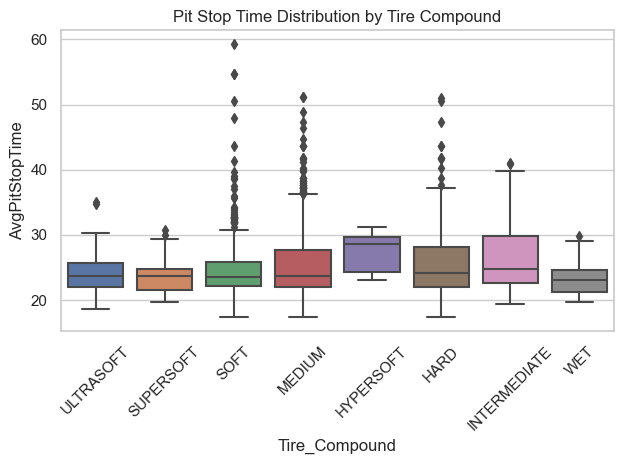

In [55]:
sns.boxplot(data=df_filtered, x="Tire_Compound", y="AvgPitStopTime")
plt.title("Pit Stop Time Distribution by Tire Compound")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#  Scatter: Aggression vs Pit Stop Time

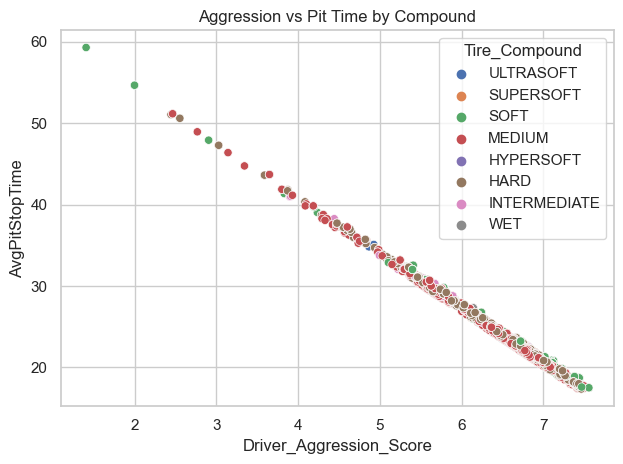

In [58]:
sns.scatterplot(data=df_filtered, x="Driver_Aggression_Score", y="AvgPitStopTime", hue="Tire_Compound")
plt.title("Aggression vs Pit Time by Compound")
plt.tight_layout()
plt.show()


# Pit Stop Time vs Track Temperature

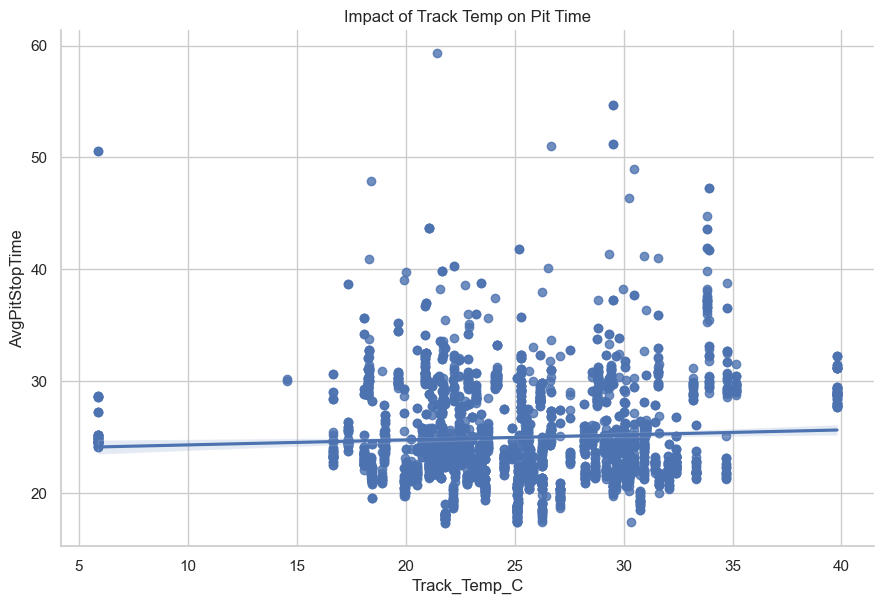

In [59]:
sns.lmplot(data=df_filtered, x="Track_Temp_C", y="AvgPitStopTime", height=6, aspect=1.5)
plt.title("Impact of Track Temp on Pit Time")
plt.show()
